# Machine Learning in Computational Biology - Assignment #2
## Task 1: Exploratory Data Analysis

This notebook focus in the exploratiory data analysis of the UCI Cleveland Heart Disease dataset.

Task's sections:
1. Dataset overview and descriptive statistics

2. Feature Assesment and Visualization


---

# Dataset & feature description
In the dataset (students_data.csv) 242 patient records and 14 attributes (13 features + 1 target variable) are included, with the task being a binary classification problem of predicting the absence (num = 0) or the presence (num = 1) of heart disease, with num being the target variable. 


### Table of features:
| Feature | Type | Description |
|---------|------|-------------|
| age | Continuous | Age in years |
| sex | Binary | Sex (1 = male, 0 = female) |
| cp | Categorical | Chest pain type (0–3): typical angina, atypical angina, non-anginal pain, asymptomatic (1-4 in the dataset)|
| trestbps | Continuous | Resting blood pressure on admission (mm Hg) |
| chol | Continuous | Serum cholesterol (mg/dl) |
| fbs | Binary | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| restecg | Categorical | Resting ECG results (0–2): normal, ST-T wave abnormality, left ventricular hypertrophy |
| thalach | Continuous | Maximum heart rate achieved during exercise |
| exang | Binary | Exercise-induced angina (1 = yes, 0 = no) |
| oldpeak | Continuous | ST depression induced by exercise relative to rest |
| slope | Categorical | Slope of the peak exercise ST segment (0–2) |
| ca | Ordinal | Number of major vessels (0–3) colored by fluoroscopy |
| thal | Categorical | Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversible defect corresponding to 3, 6, 7 in the dataset)|
    

Furthermore, during the exploratory analysis, the dataset will be checked for duplicate rows, missing values, data types, outliers, and class imbalance, since their presence or distribution can affect the reliability of the machine learning models, while preprocessing steps such as imputation, scaling, and encoding will be included later inside the cross-validation pipeline to avoid data leakage.

# Libraries

In [1]:
import random
import numpy as np
import pandas as pd

#For the PCA
#Setting the seed 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#Importing the plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Adjusting the visualization of the plots through seaborn library
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120

# Setting the path of the data 
DATA_PATH = '../data/students_dataset.csv'


# Loading the raw data

In [2]:
#Examining the Shape of the data
df_raw = pd.read_csv(DATA_PATH) # saving as a dataframe
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (242, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0,0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1


## 1. Dataset Overview and Descriptive Statistics



In [3]:
# Printing the data types of each column for showing the format of the dataset, and printing the descriptive statistics of it 
print('Column data types:\n',df_raw.dtypes)
print('Descriptive Statistics:')
df_raw.describe().round(2)

Column data types:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object
Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,242.00,242.00,242.00,242.00,242.00,242.00,242.00,242.00,242.00,242.00,242.00,241.00,241.00,242.00
mean,54.55,0.68,3.15,130.96,249.84,0.14,0.98,149.96,0.33,1.00,1.59,0.61,4.71,0.46
std,9.00,0.47,0.98,17.62,52.85,0.35,1.00,22.69,0.47,1.12,0.61,0.88,1.95,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,2.25,120.00,212.00,0.00,0.00,134.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,244.50,0.00,0.00,153.50,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,277.75,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


### Duplicate rows

In [4]:
# Checking the data for duplicate rows
n_dups = df_raw.duplicated().sum()
print(f'Duplicate rows: {n_dups}')

Duplicate rows: 0


### Missing Values

In [5]:
# Counting the total mssing values of each col and presenting them as % in the total data set
missing_values = df_raw.isnull().sum()
missing_pct = (missing_values / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing_values, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
print('Features with missing values:\n',missing_df)

Features with missing values:
       Count  Percentage
ca        1        0.41
thal      1        0.41


**Comment:** Features `ca` and `thal` seems to be the only variables with missing values, with each one containing one missing entry, corresponding to a missingness rate of 0.41%. Therefore, due to the low missingness rate, median/mode imputation is considered as an appropriate approach, with these imputation steps not being applied during EDA, but later inside each CV fold to prevent data leakage.

### Outliers

In [6]:
#To define potential outliers, the IQR method to flag potential outliers in continuous features only was used, 
#since this method assumes a meaningful numerical scale.

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

#function of outlier count in each col
def count_outliers_iqr(series: pd.Series) -> int:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1  #calculation of iqr
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr # defining the lower and higher bound
    return ((series < lo) | (series > hi)).sum()

outlier_counts = {col: count_outliers_iqr(df_raw[col].dropna()) for col in continuous_cols}

print('Outlier counts:')
for col, cnt in outlier_counts.items():
    print(f'  {col}: {cnt}')


Outlier counts:
  age: 0
  trestbps: 6
  chol: 5
  thalach: 1
  oldpeak: 4


**Comment:** The resulting values were not removed at this stage since extreme clinical measurements may correspond to real patient profiles, such as very high `serum cholesterol`, or `resting blood pressure on admission` which can be real risk factors and are having a lot of outliers in the dataset, with the `trestbps` having the most (6). Therefore, the inspection of their presence was mainly for identification and for achieving robust preprocessing and careful model evaluation in later steps.



### Class Imbalance

,Count,Percentage
0,131,54.1
1,111,45.9


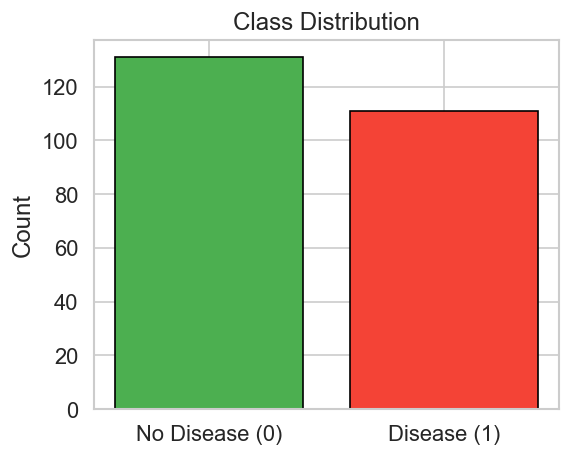

Imbalance ratio: 1.18


In [7]:
# Since class imbalance affects the choice of evaluation metrics and may require stratified splitting, inspection is needed.
class_counts = df_raw['num'].value_counts().sort_index()
class_pct    = (class_counts / len(df_raw) * 100).round(1)
class_imb_df = pd.DataFrame({'Count': class_counts.values, 'Percentage': class_pct.values})
display(class_imb_df)

# Figure plotting of the class imbalance 
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No Disease (0)', 'Disease (1)'], class_counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.savefig('../figures/class_imbalance.png', bbox_inches='tight')
plt.show()

# Calculating the imbalance ratio
imbalance_ratio = (class_counts.max()/class_counts.min()).round(2)
print(f'Imbalance ratio: {imbalance_ratio}')


**Comment:** The dataset shows a slight class imbalance, a bit over 1, a result that supports `a)` the use of `stratified K-fold` splits throughout all CV loops in order to preserve the class proportions across folds and `b)` the selection of complementary metrics such as `balanced accuracy, MCC, recall, specificity, AUC`, and `F1-score`, instead of relying only on accuracy.

---

# 2. Feature Assessment & Visualization

### Box plots of Feature Distributions

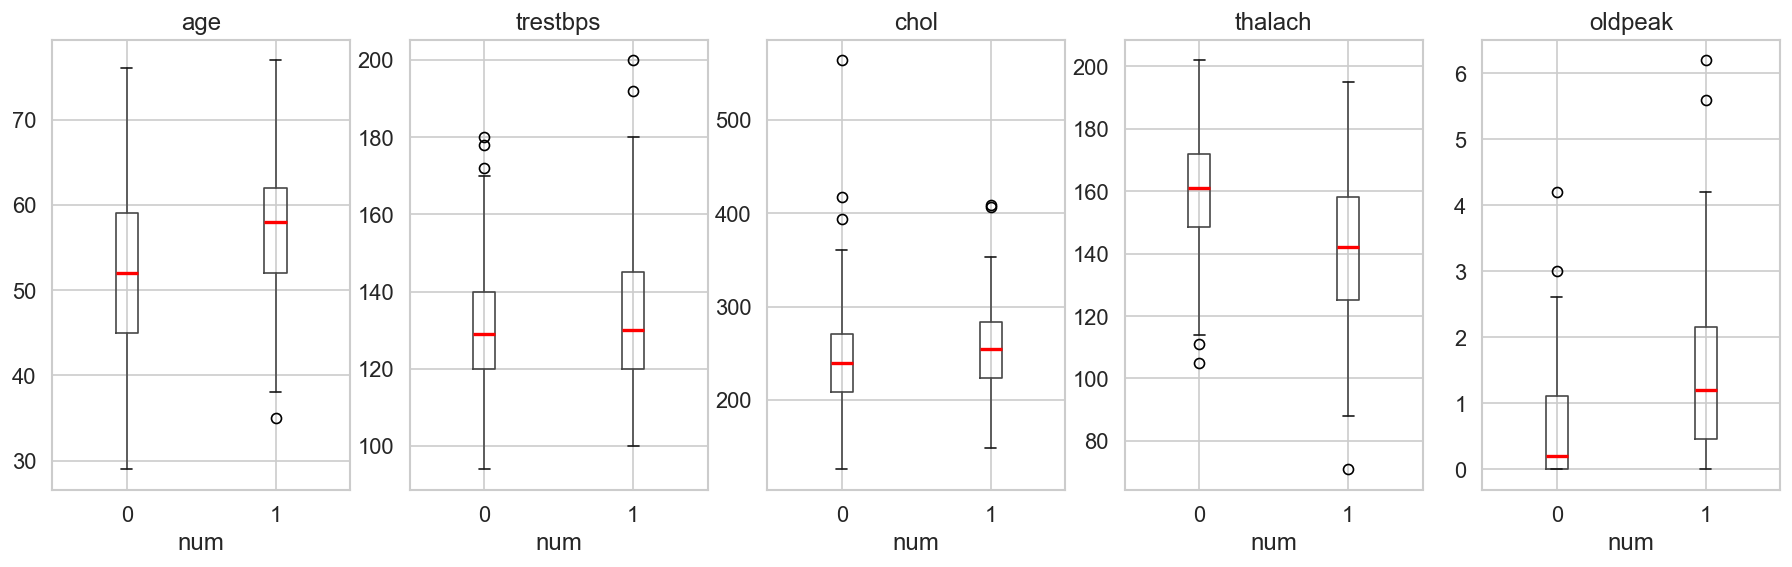

In [8]:
# The boxplots were created only for continuous features since they summarize numerical distributions through the median, 
# interquartile range, spread, and potential outliers.
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 5), sharey=False)
for ax, col in zip(axes, continuous_cols):
    df_raw.boxplot(column=col, by='num', ax=ax, medianprops=dict(color='red', linewidth=2))
  
plt.suptitle('')   
plt.savefig('../figures/feature_con_boxplots.png', bbox_inches='tight')
plt.show()

**Comment:** Through the boxplots, the distributions of the continuous features were compared between patients without heart disease `(0)` and patients with heart disease `(1)`. 
Specifically, it can be observed that patients with heart disease tend to have higher median `age` and higher median `oldpeak`, while they show lower median `thalach`, namely a lower maximum heart rate achieved during exercise, observationsn suggesting that `age`, `oldpeak`, and `thalach` may be informative features for distinguishing the two classes.  
On the contrary, `trestbps` and `chol` show more overlapping distributions between the two groups, suggesting weaker class separation based only on these individual features. Although, previously, both of those variables had shown the most potential outliers, which may correspond to real clinical measurements, therefore they are not exclude.

### Bar plots for the rest Feature Distributions

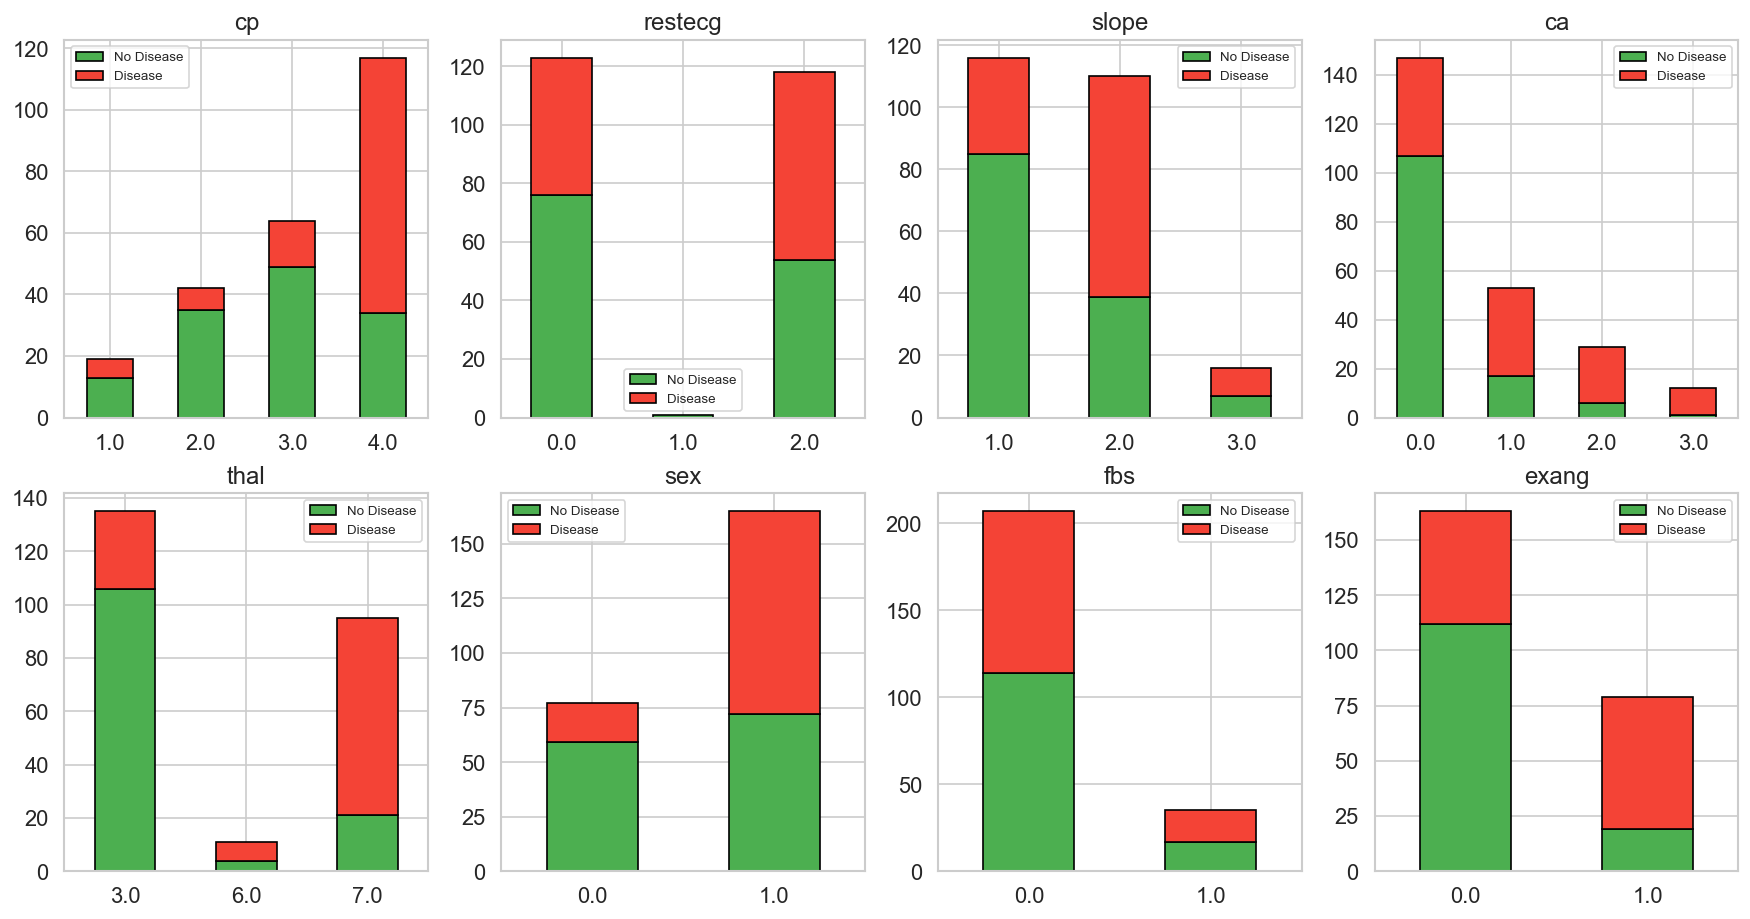

In [9]:
#Rest of the features distribution in stack bar plots for examination with rescept to the target variable (num)
rest_cols = ['cp', 'restecg', 'slope', 'ca', 'thal', 'sex', 'fbs', 'exang']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, col in zip(axes, rest_cols):
    rf = df_raw.groupby([col, 'num']).size().unstack(fill_value=0)
    rf.plot(kind='bar', ax=ax, stacked=True,color=['#4CAF50', '#F44336'], edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(['No Disease', 'Disease'], fontsize=8)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('')   
plt.savefig('../figures/rest_features_distribution.png', bbox_inches='tight')
plt.show()




**Comment:** The stacked bar plots show that `cp`, `ca`, `thal`, `exang`, and `slope` present possible differences in class composition across categories, suggesting that they may be informative for classification. Specifically, `cp` type 4, higher `ca` values, `thal = 7`, and `exang = 1` appear to be more frequently associated with heart disease. 

However, `restecg`, `sex`, and `fbs` show weaker and unsure visual separation, possibly due to the imbalance of different samples, although they may still contribute useful information in combination with other predictors.



### Heatmap - Pearson Correlation analysis between features

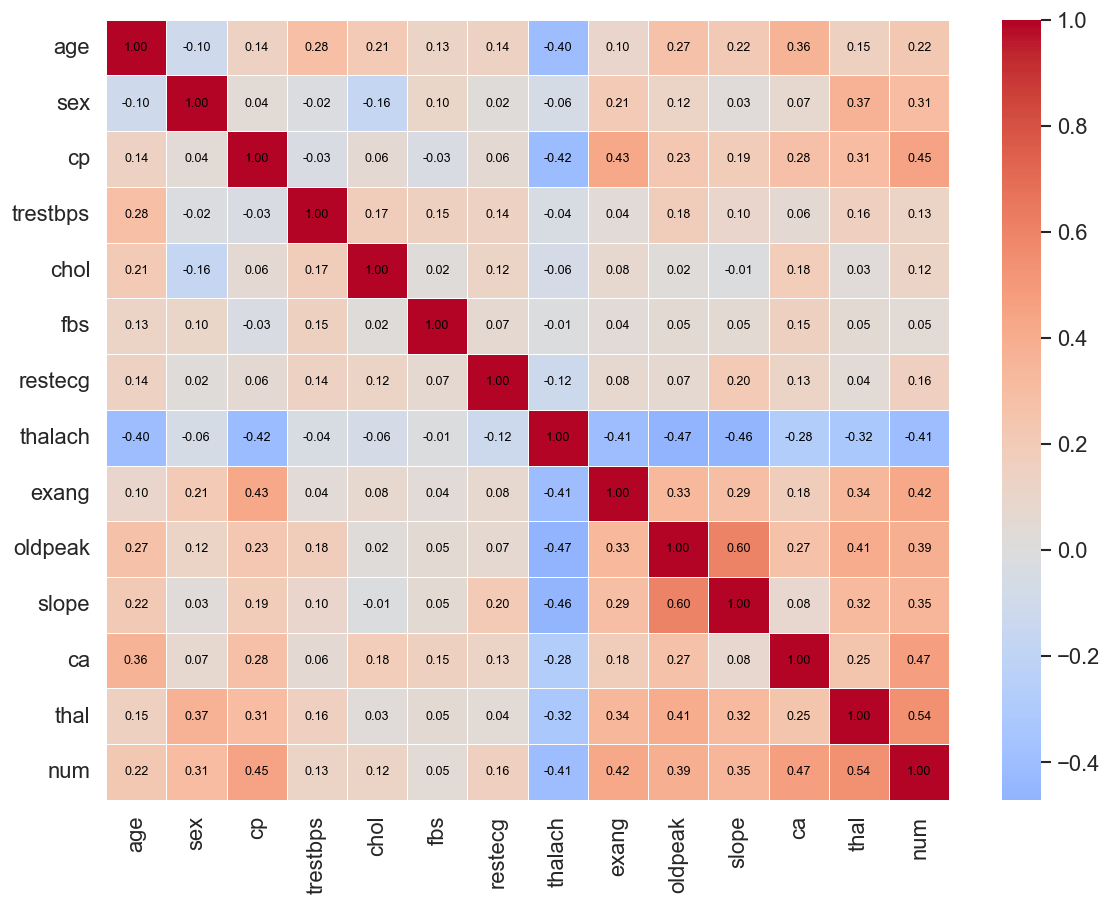

In [10]:
# Spearman correlation between the features and the target value num 
# Spearman correlation was preferred over Pearson because the dataset includes several binary, ordinal, 
# and discretely encoded clinical variables. 

df = df_raw.copy()
for col in df_raw.columns:
    if df_raw[col].isnull().any():
        df[col] = df_raw[col].fillna(df_raw[col].median()) #filling the na values of the dataset with the median value, only for visualization

#Calculation of Spearman correlation
corr = df.corr(method='spearman')

#Plotting the Spearman correlation with seaborn for heatmap
fig, ax = plt.subplots(figsize=(10, 8))
heatmap= sns.heatmap(corr, annot=False, cmap='coolwarm', fmt='.2f', center=0, linewidths=0.5, ax=ax)


# Adding manually the annotation for every cell
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j + 0.5, i + 0.5, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7.5, color='black', )

plt.suptitle('')  
plt.tight_layout()
plt.savefig('../figures/Spearman_correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Comment:** The heatmap was used only as an exploratory tool, and according to its results, the relationship between the target variable `num` and the different features shows that the strongest positive associations are observed for `thal`, `ca`, `cp`, and `exang` (disease related), while `thalach` shows the strongest negative association with the target (no disease related). 

Other features, such as `fbs`, `chol`, and `trestbps`, show weaker correlations with `num`, suggesting weaker individual linear or monotonic associations with the target.

The positive relationship with `age` seems to be expected since the older someone is, the bigger the possibility of adapting to a heart-related disease.

### PCA - Dimensionality reduction technique

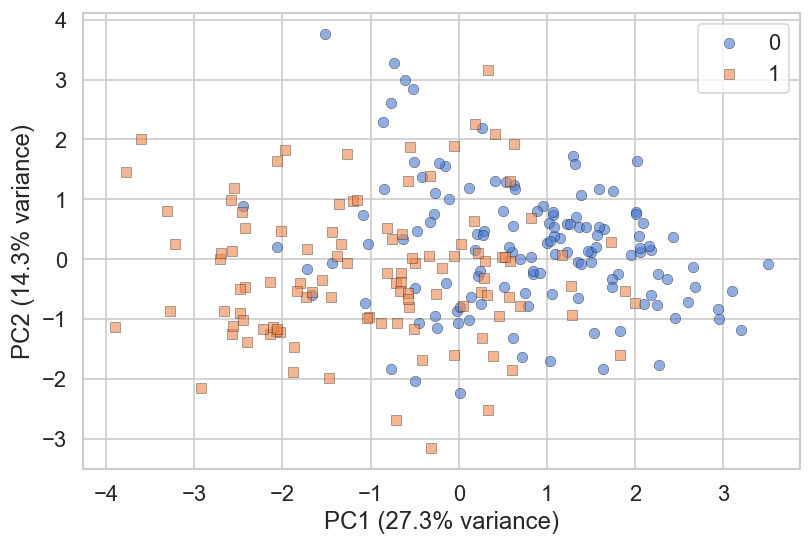

Total variance by 2 PCs: 41.7%


In [ ]:
#PCA was used only for visualizing if the classes are separable in lower-dimensional projection of the feature space.
#The preproccessing steps for the PCA were only fitted for this visualization and not for model training.

#Separating the rest of the features into the categories that they belong, since they need different preprocessing
binary_cols = ['sex', 'fbs', 'exang']
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
ordinal_cols = ['ca']
features = continuous_cols + binary_cols + categorical_cols + ordinal_cols
target = 'num'

# Preprocessing for PCA visualization
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
#median for the missing values and scaling for continuous features

categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
# into the na values importing the most_frequent and
# making the categories into dummy variables to not thing that are differet and comparable numerically


preprocessor_pca = ColumnTransformer([
    ('continuous', numeric_pipeline, continuous_cols),
    ('binary', SimpleImputer(strategy='most_frequent'), binary_cols),
    ('ordinal', SimpleImputer(strategy='median'), ordinal_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])


X = df_raw[features]
y = df_raw[target]
X_ready = preprocessor_pca.fit_transform(X)

#Creating a PCA object with 2 components in order to visualize it in 2D scatter plot
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_ready)


#Figure plotting 
fig, ax = plt.subplots(figsize=(7, 5))
for label, marker in [(0, 'o'), (1, 's')]:
    idx = y == label
    ax.scatter( X_pca[idx, 0],X_pca[idx, 1], label=f'{label}',alpha=0.6,edgecolors='black',linewidths=0.3,marker=marker,s=40)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
ax.legend()
plt.suptitle('')  
plt.tight_layout()
plt.savefig('../figures/pca.png', bbox_inches='tight')
plt.show()


print(f'Total variance - 2 PCs: {pca.explained_variance_ratio_.sum() * 100:.1f}%')

**Comment:** The two classes show partial but incomplete separation in the first two principal components, with total variance 41.7%. The observed overlap possibly suggests that a non-linear classifier may be needed to fully distinguish the classes and that all 13 features (not just 2 PCs) are likely needed.